# Quantum Pricing Optimization with QAOA
### A Qiskit-based benchmarking suite for combinatorial pricing problems

---

## Overview

This project demonstrates the application of the **Quantum Approximate Optimization Algorithm (QAOA)** to a simplified automotive pricing problem — modeling the task of assigning optimal price levels across a set of products subject to demand constraints and cross-product interdependencies.

The core workflow mirrors the research pipeline relevant to industrial quantum optimization:

1. **Problem formulation** — encode a pricing problem as a QUBO (Quadratic Unconstrained Binary Optimization)
2. **Quantum translation** — convert the QUBO into an Ising Hamiltonian suitable for a quantum circuit
3. **QAOA optimization** — run a variational quantum circuit and tune parameters classically
4. **Benchmarking** — compare QAOA against exact (brute force) and classical heuristic (simulated annealing) solvers

---

## Motivation

Pricing in the industry context is a compelling target for quantum optimization as it combines:

- **High-dimensional configuration spaces** — many products, each with multiple discrete price levels
- **Combinatorial structure** — the joint assignment of prices is a discrete optimization problem
- **Competitive interdependencies** — demand for one product depends on the price of others
- **Hard constraints** — each product must be assigned exactly one price level

These properties make the problem intractable for exhaustive classical search at scale, and a natural candidate for quantum-enhanced solvers such as QAOA or Decoded Quantum Interferometry (DQI).

---

## Problem Formulation

### Classical Setup

Given $n$ products and $k$ discrete price levels each, the goal is to maximize total expected revenue:

$$\max \sum_{i=1}^{n} p_i \cdot d_i(p_i) - \lambda \sum_{i \neq j} c_{ij} \cdot d_i \cdot d_j$$

where $p_i$ is the price of product $i$, $d_i(p_i)$ is a linear demand curve, $c_{ij}$ captures cross-product demand sensitivity, and $\lambda$ is a penalty weight.

### Binary Encoding (One-Hot)

Each product $i$ is assigned a price level $l$ via a one-hot binary variable:

$$x_{il} = 1 \text{ if product } i \text{ takes price level } l, \text{ else } 0$$

with the constraint $\sum_l x_{il} = 1$ for all $i$.

For $n=3$ products and $k=3$ price levels this gives **9 binary variables**, small enough to simulate exactly and benchmark rigorously.

### QUBO Matrix

The problem is cast as minimizing $\mathbf{x}^T Q \mathbf{x}$ where:

$$Q = -Q_{\text{revenue}} + A \cdot Q_{\text{constraint}} + \lambda \cdot Q_{\text{cross}}$$

- $Q_{\text{revenue}}$: diagonal revenue terms
- $Q_{\text{constraint}}$: one-hot penalty with strength $A$
- $Q_{\text{cross}}$: off-diagonal cross-product interference terms

---

## QAOA Algorithm

### From QUBO to Ising Hamiltonian

The QUBO is converted to an Ising Hamiltonian via the substitution $x_i = \frac{1 - z_i}{2}$:

$$H_C = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j$$

where $Z_i$ are Pauli-Z operators, $h_i$ are local fields, and $J_{ij}$ are spin couplings derived analytically from $Q$.

### Circuit Structure

The QAOA circuit of depth $p$ alternates two unitaries starting from the uniform superposition $|+\rangle^{\otimes n}$:

$$|\psi_p(\gamma, \beta)\rangle = e^{-i\beta_p H_B} e^{-i\gamma_p H_C} \cdots e^{-i\beta_1 H_B} e^{-i\gamma_1 H_C} |+\rangle^{\otimes n}$$

- **Cost unitary** $e^{-i\gamma H_C}$: applies $R_Z(2\gamma h_i)$ and $R_{ZZ}(2\gamma J_{ij})$ gates — encodes the pricing problem into quantum phases
- **Mixer unitary** $e^{-i\beta H_B}$: applies $R_X(2\beta)$ to every qubit — converts phase differences into measurable probability differences

### Classical Optimization Loop

The variational parameters $(\gamma_1, ..., \gamma_p, \beta_1, ..., \beta_p)$ are tuned by a classical COBYLA optimizer minimizing the expectation value:

$$\langle H_C \rangle \approx \frac{1}{N_{\text{shots}}} \sum_{k=1}^{N} E(\mathbf{x}_k)$$

estimated via Monte Carlo sampling with $N$ = `n_shots` circuit executions per iteration.

---


### Convergence Tracking

The QAOA optimizer is tracked across all iterations via four metrics:

| Panel | Metric | Interpretation |
|---|---|---|
| Energy + std band | Mean $\langle H_C \rangle$ ± spread | Optimizer progress and estimate reliability |
| Min + running best | Lowest sampled energy per iteration | Whether the optimal solution is ever visited |
| Valid fraction | % of shots satisfying one-hot constraint | Constraint learning and penalty tuning |
| Std deviation | Width of energy distribution | Exploration (high) vs. convergence (low) |

---

## Key Design Decisions

**Why QUBO?** QUBO is the standard input format for quantum optimization hardware (D-Wave, gate-based via QAOA, and emerging approaches like DQI). Formulating the pricing problem as a QUBO makes this work directly transferable to real quantum hardware.

**Why one-hot encoding?** Each product must have exactly one price — a natural one-hot constraint. This is enforced via a quadratic penalty in $Q$ with strength $A$. Tuning $A$ relative to the revenue terms is a critical hyperparameter: too small and the optimizer ignores the constraint; too large and it dominates the revenue signal.

**Why COBYLA?** Derivative-free optimization avoids the cost of computing quantum gradients analytically. For small parameter counts (`reps=1,2`) COBYLA is efficient. For deeper circuits, gradient-based methods using the parameter-shift rule would be preferred.

**Why `n_shots=2048`?** The statistical error on $\langle H_C \rangle$ scales as $\sigma / \sqrt{N}$. At 2048 shots the relative error is ~2%, providing a reliable signal for the optimizer without excessive runtime.

---

## Limitations and Next Steps

- **Noise model**: all simulations use a statevector simulator (noiseless). A natural extension is adding a depolarizing noise model via `AerSimulator` to assess performance on near-term hardware.
- **Problem scale**: the 9-qubit instance is exactly solvable. Scaling to larger instances (more products/price levels) would reveal where classical solvers begin to struggle and quantum methods become competitive.
- **DQI extension**: this project uses QAOA as a proxy for the DQI framework. A direct implementation of DQI decoding for the pricing QUBO is a natural next step.
- **Penalty tuning**: the one-hot penalty strength $A$ is fixed. A systematic study of how $A$ affects the valid fraction and solution quality would be a meaningful contribution.

---



In [2]:
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from qiskit.primitives import StatevectorEstimator, StatevectorSampler
from scipy.optimize import minimize
import itertools

import numpy as np
from qiskit.circuit.library import QAOAAnsatz

import matplotlib.pyplot as plt
import time

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter


## Class: `PricingProblem`

This class is the foundation of the entire pipeline. It encodes the pricing problem into a QUBO matrix and provides utilities for decoding and evaluating solutions.


In [20]:


class PricingProblem:
    
    """
    Simplified dynamic pricing problem for n products, k price levels each.
    Encodes as QUBO for quantum optimization.
    """

    def __init__(self, n_products=3, n_price_levels=3, penalty=5.0, cross_penalty=0.5):
        
        self.n = n_products
        self.k = n_price_levels
        self.penalty = penalty          # one-hot constraint penalty A
        self.cross_penalty = cross_penalty  # lambda for cross-product effects
        self.n_vars = n_products * n_price_levels

        # Price levels: e.g. 0.8, 1.0, 1.2 (normalized around base price)
        self.price_levels = np.linspace(0.8, 1.2, n_price_levels)

        # Demand: linear price-demand curve d(p) = 1 - alpha * p
        self.alpha = np.array([0.6, 0.5, 0.7])  # price sensitivity per product

        # Cross-product sensitivity matrix (symmetric)
        self.cross = np.array([
            [0.0,  0.2,  0.1],
            [0.2,  0.0,  0.3],
            [0.1,  0.3,  0.0]
        ])

    def demand(self, product_idx, price):
        
        """Linear demand curve."""
        return max(0, 1 - self.alpha[product_idx] * price)

    def revenue(self, product_idx, price_level_idx):
        
        """Revenue = price * demand."""
        p = self.price_levels[price_level_idx]
        d = self.demand(product_idx, p)
        
        return p * d

    def var_index(self, i, l):
        
        """Map (product i, price level l) -> flat variable index."""
        
        return i * self.k + l

    def build_qubo(self):
        
        """
        Build QUBO matrix Q such that we minimize x^T Q x.
        Encodes: maximize revenue - cross penalties, subject to one-hot constraints.
        """
        Q = np.zeros((self.n_vars, self.n_vars))

        # --- Revenue terms (diagonal, negated for minimization) ---
        for i in range(self.n):
            
            for l in range(self.k):
                idx = self.var_index(i, l)
                Q[idx, idx] -= self.revenue(i, l)

        # --- One-hot constraint: (sum_l x_il - 1)^2 ---
        # Expands to: sum_l x_il^2 + 2*sum_{l<l'} x_il * x_il' - 2*sum_l x_il + 1
        # In QUBO: diagonal gets -A, off-diagonal pairs get +2A
        
        for i in range(self.n):
            
            for l in range(self.k):
                
                idx = self.var_index(i, l)
                Q[idx, idx] += self.penalty * (1 - 2)  # x^2=x for binary, net: -A
                for l2 in range(l + 1, self.k):
                    
                    idx2 = self.var_index(i, l2)
                    Q[idx, idx2] += 2 * self.penalty

        # --- Cross-product demand interference (off-diagonal) ---
        for i in range(self.n):
            for j in range(i + 1, self.n):
                for l in range(self.k):
                    for l2 in range(self.k):
                        
                        idx  = self.var_index(i, l)
                        idx2 = self.var_index(j, l2)
                        d_i  = self.demand(i, self.price_levels[l])
                        d_j  = self.demand(j, self.price_levels[l2])
                        
                        if idx < idx2:
                            Q[idx, idx2] += self.cross_penalty * self.cross[i, j] * d_i * d_j
                        else:
                            Q[idx2, idx] += self.cross_penalty * self.cross[i, j] * d_i * d_j

        return Q
    
    

    def decode_solution(self, bitstring):
        
        """
        Decode a bitstring solution into (product, price_level, revenue) assignments.
        bitstring: list or array of 0/1, length n*k
        """
        assignments = []
        total_revenue = 0
        valid = True

        for i in range(self.n):
            
            bits = [bitstring[self.var_index(i, l)] for l in range(self.k)]
            
            if sum(bits) != 1:
                valid = False
                assignments.append((i, None, 0))
            else:
                l = bits.index(1)
                r = self.revenue(i, l)
                total_revenue += r
                assignments.append((i, l, round(r, 4)))
                

        return assignments, round(total_revenue, 4), valid

    
    def evaluate_qubo(self, bitstring, Q):
        
        """Evaluate x^T Q x for a given bitstring."""
        x = np.array(bitstring)
        
        return float(x @ Q @ x)
    
    
    
    
    
    

In [5]:


def brute_force(problem: PricingProblem):
    
    """
    Exact solver: enumerate all valid one-hot assignments.
    Feasible only for small n, k.
    """
    Q = problem.build_qubo()
    best_energy = np.inf
    best_bits = None

    # Only iterate over valid one-hot combinations
    price_combinations = itertools.product(range(problem.k), repeat=problem.n)

    for combo in price_combinations:
        
        bits = [0] * problem.n_vars
        for i, l in enumerate(combo):
            bits[problem.var_index(i, l)] = 1

        energy = problem.evaluate_qubo(bits, Q)
        
        if energy < best_energy:
            best_energy = energy
            best_bits = bits[:]

    assignments, total_rev, _ = problem.decode_solution(best_bits)
    
    return best_bits, best_energy, total_rev










def simulated_annealing(problem: PricingProblem, n_iterations=5000, T_start=5.0, T_end=0.01):
    
    """
    Classical simulated annealing baseline.
    Moves: randomly reassign one product to a different price level.
    """
    
    Q = problem.build_qubo()

    # Random valid initialization
    current_bits = [0] * problem.n_vars
    
    for i in range(problem.n):
        
        l = np.random.randint(problem.k)
        current_bits[problem.var_index(i, l)] = 1

    current_energy = problem.evaluate_qubo(current_bits, Q)
    best_bits = current_bits[:]
    best_energy = current_energy

    T = T_start
    cooling = (T_end / T_start) ** (1.0 / n_iterations)
    

    for _ in range(n_iterations):
        
        # Propose move: change one product's price level
        new_bits = current_bits[:]
        i = np.random.randint(problem.n)
        old_l = next(l for l in range(problem.k) if new_bits[problem.var_index(i, l)] == 1)
        new_l = np.random.choice([l for l in range(problem.k) if l != old_l])

        new_bits[problem.var_index(i, old_l)] = 0
        new_bits[problem.var_index(i, new_l)] = 1

        new_energy = problem.evaluate_qubo(new_bits, Q)
        delta = new_energy - current_energy

        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            current_bits = new_bits
            current_energy = new_energy

        if current_energy < best_energy:
            best_energy = current_energy
            best_bits = current_bits[:]

        T *= cooling
        

    assignments, total_rev, valid = problem.decode_solution(best_bits)
    
    
    return best_bits, best_energy, total_rev





In [23]:



def qubo_to_ising(Q):
    
    """
    Convert QUBO matrix Q to Ising h (local fields) and J (couplings).
    Substitution: x_i = (1 - z_i) / 2
    Returns offset (constant), h (1D array), J (upper triangular matrix)
    """
    n = Q.shape[0]
    h = np.zeros(n)
    J = np.zeros((n, n))
    offset = 0.0

    for i in range(n):
        for j in range(i, n):
            
            if i == j:
                # x_i^2 = x_i, substitution: x_i = (1-z_i)/2
                h[i] -= Q[i, i] / 2
                offset += Q[i, i] / 2
            else:
                q = Q[i, j]
                J[i, j] += q / 4
                h[i]     -= q / 4
                h[j]     -= q / 4
                offset   += q / 4

    return offset, h, J








def build_cost_hamiltonian(problem: PricingProblem):
    
    """Build Qiskit SparsePauliOp cost Hamiltonian from QUBO."""
    Q = problem.build_qubo()
    n = problem.n_vars
    offset, h, J = qubo_to_ising(Q)

    pauli_list = []

    # Single-qubit Z terms
    for i in range(n):
        
        if abs(h[i]) > 1e-10:
            z_str = ['I'] * n
            z_str[i] = 'Z'
            pauli_list.append((''.join(reversed(z_str)), h[i]))

    # Two-qubit ZZ terms
    for i in range(n):
        for j in range(i + 1, n):
            
            if abs(J[i, j]) > 1e-10:
                zz_str = ['I'] * n
                zz_str[i] = 'Z'
                zz_str[j] = 'Z'
                pauli_list.append((''.join(reversed(zz_str)), J[i, j]))

    cost_op = SparsePauliOp.from_list(pauli_list)
    
    return cost_op, offset












def run_qaoa(problem: PricingProblem, reps=2, n_shots=2048, verbose=True):
    
    cost_op, offset = build_cost_hamiltonian(problem)
    Q = problem.build_qubo()

    qaoa = QAOAAnsatz(cost_operator=cost_op, reps=reps)
    qaoa.measure_all()
    sampler = StatevectorSampler()

    # --- Tracking state ---
    history = {
        'mean_energy':    [],   # <H_C> at each iteration
        'min_energy':     [],   # best energy seen so far
        'std_energy':     [],   # spread of sampled energies
        'best_so_far':    [],   # running best QUBO energy
        'valid_fraction': [],   # fraction of valid one-hot samples
        'iteration':      [],   # iteration counter
        'params':         [],   # parameter values at each step
    }
    iteration = [0]
    running_best = [np.inf]

    
    
    def objective(params):
        
        iteration[0] += 1

        pub = (qaoa, params)
        result = sampler.run([pub], shots=n_shots).result()
        counts = result[0].data.meas.get_counts()
        total_shots = sum(counts.values())

        # --- Per-sample statistics ---
        energies = []
        n_valid  = 0

        for bitstring, count in counts.items():
            
            bits = [int(b) for b in reversed(bitstring)]
            e = problem.evaluate_qubo(bits, Q)
            _, _, valid = problem.decode_solution(bits)

            energies.extend([e] * count)   # weight by measurement count
            if valid:
                n_valid += count

        energies = np.array(energies)
        mean_e   = float(np.mean(energies))
        min_e    = float(np.min(energies))
        std_e    = float(np.std(energies))
        valid_f  = n_valid / total_shots

        # Update running best
        if min_e < running_best[0]:
            running_best[0] = min_e

        # Record
        history['mean_energy'].append(mean_e)
        history['min_energy'].append(min_e)
        history['std_energy'].append(std_e)
        history['best_so_far'].append(running_best[0])
        history['valid_fraction'].append(valid_f)
        history['iteration'].append(iteration[0])
        history['params'].append(params.copy())

        if verbose and iteration[0] % 20 == 0:
            
            print(f"  iter {iteration[0]:>4d} | "
                  f"mean E={mean_e:+.4f} | "
                  f"best={running_best[0]:+.4f} | "
                  f"valid={valid_f:.2%}")

        return mean_e

    
    
    

    # --- Optimize ---
    n_params = len(qaoa.parameters)
    x0 = np.random.uniform(-np.pi, np.pi, n_params)

    if verbose:
        print(f"Running QAOA | reps={reps} | "
              f"params={n_params} | shots={n_shots}")

    opt_result = minimize(
        objective, x0,
        method='COBYLA',
        options={'maxiter': 700, 'rhobeg': 0.1, 'rhoend': 1e-5}
    )

    # --- Final sampling ---
    pub = (qaoa, opt_result.x)
    final_result = sampler.run([pub], shots=n_shots).result()
    counts = final_result[0].data.meas.get_counts()

    best_bits = None
    best_energy = np.inf

    for bitstring, count in sorted(counts.items(), key=lambda x: -x[1]):
    
        bits = [int(b) for b in reversed(bitstring)]
        _, _, valid = problem.decode_solution(bits)
        
        if valid:
            e = problem.evaluate_qubo(bits, Q)
            if e < best_energy:
                best_energy = e
                best_bits = bits
                
            break

    if best_bits is None:
        
        best_key = min(counts.keys(),
                       key=lambda bs: problem.evaluate_qubo(
                           [int(b) for b in reversed(bs)], Q))
        best_bits   = [int(b) for b in reversed(best_key)]
        best_energy = problem.evaluate_qubo(best_bits, Q)

    _, total_rev, valid = problem.decode_solution(best_bits)
    
    
    
    
    
    return best_bits, best_energy, total_rev, counts, history



## Benchmark: Quantum vs Classical Solvers

This section runs all three solvers on the same pricing problem instance and compares
their performance side by side.


1. **Brute Force** — enumerates all valid one-hot assignments exhaustively and returns
   the guaranteed optimal solution. Feasible only for small instances but provides the
   ground truth for all approximation ratios.

2. **Simulated Annealing** — a classical heuristic that explores the solution space
   stochastically by accepting worse solutions with a temperature-dependent probability.
   Serves as the classical performance baseline.

3. **QAOA** — runs the variational quantum circuit with `qaoa_reps` layers, tracking
   the full optimization trajectory (mean energy, min energy, valid fraction, std dev)
   across all iterations.

### Output

- Console table with revenue, QUBO energy, and approximation ratio per solver
- `benchmark_results.png` — side-by-side bar charts of revenue, approximation ratio,
  and runtime
- `qaoa_convergence.png` — 4-panel QAOA optimization trajectory dashboard

### Key parameter: approximation ratio

$$r = \frac{\text{revenue}_{\text{solver}}}{\text{revenue}_{\text{optimal}}} \in (0, 1)$$

A ratio of 1.0 means the solver found the optimal solution. This is the primary metric
for evaluating QAOA quality relative to the exact solution.


  Pricing Problem: 3 products × 3 price levels
  Variables: 9 binary qubits

[Brute Force] (0.000s)
  Revenue: 1.2680 | Energy: -4.1976
  Product 0: price level 0 (p=0.80) → revenue 0.416
  Product 1: price level 1 (p=1.00) → revenue 0.5
  Product 2: price level 0 (p=0.80) → revenue 0.352

[Simulated Annealing] (0.221s)
  Revenue: 1.2680 | Energy: -4.1976
  Product 0: price level 0 (p=0.80) → revenue 0.416
  Product 1: price level 1 (p=1.00) → revenue 0.5
  Product 2: price level 0 (p=0.80) → revenue 0.352
Running QAOA | reps=2 | params=4 | shots=2048


C:\Users\the_w\anaconda3\envs\py310\lib\site-packages\scipy\optimize\_minimize.py:744: OptimizeWarning: Unknown solver options: rhoend
  res = _minimize_cobyla(fun, x0, args, constraints, callback=callback,
C:\Users\the_w\anaconda3\envs\py310\lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
C:\Users\the_w\anaconda3\envs\py310\lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
C:\Users\the_w\anaconda3\envs\py310\lib\site-packages\scipy\sparse\_index.py:155: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


  iter   20 | mean E=-3.0981 | best=-4.1976 | valid=30.81%
  iter   40 | mean E=-3.1661 | best=-4.1976 | valid=25.54%

[QAOA reps=2] (174.855s)
  Revenue: 1.0720 | Energy: -4.0432 | Valid: True
  Product 0: price level 1 (p=1.00) → revenue 0.4
  Product 1: price level 2 (p=1.20) → revenue 0.48
  Product 2: price level 2 (p=1.20) → revenue 0.192

  Approximation Ratio (vs Brute Force optimum)
  Brute Force         : 1.0000
  Sim. Annealing      : 1.0000
  QAOA                : 0.8454

  Plot saved to benchmark_results.png


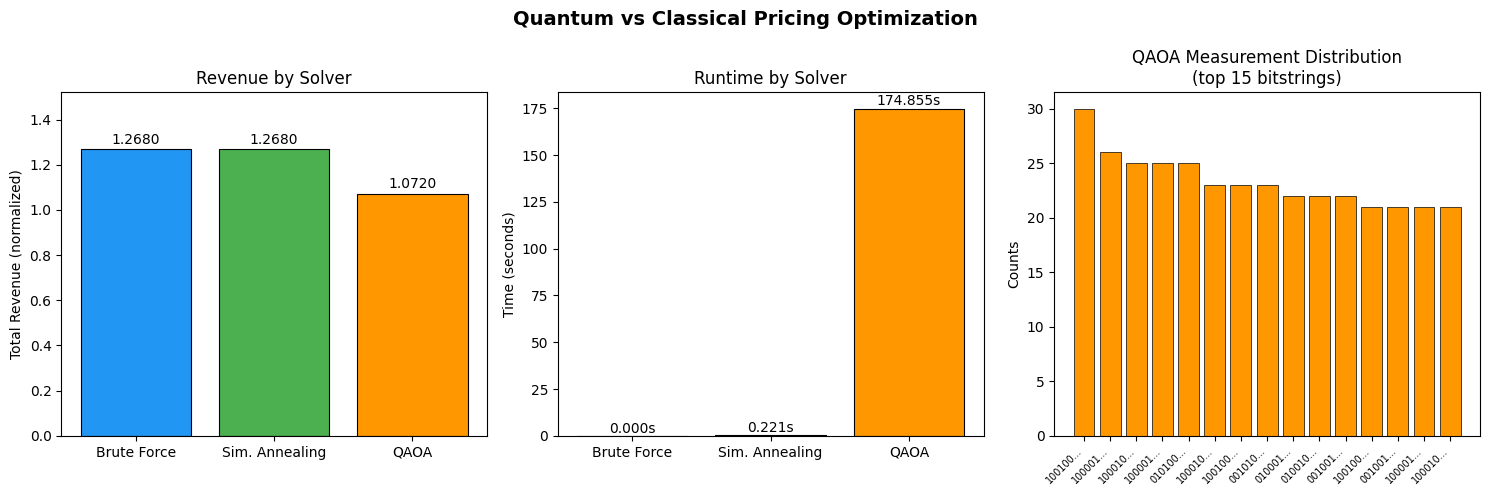

In [24]:

def run_benchmark(n_products=3, n_price_levels=3, qaoa_reps=2):
    
    problem = PricingProblem(n_products=n_products,
                             n_price_levels=n_price_levels)

    print(f"\n{'='*55}")
    print(f"  Pricing Problem: {n_products} products × {n_price_levels} price levels")
    print(f"  Variables: {problem.n_vars} binary qubits")
    print(f"{'='*55}")

    results = {}

    # --- Brute Force ---
    t0 = time.time()
    bf_bits, bf_energy, bf_rev = brute_force(problem)
    bf_time = time.time() - t0
    results['Brute Force'] = {'energy': bf_energy, 'revenue': bf_rev, 'time': bf_time}
    assignments, _, _ = problem.decode_solution(bf_bits)
    print(f"\n[Brute Force] ({bf_time:.3f}s)")
    print(f"  Revenue: {bf_rev:.4f} | Energy: {bf_energy:.4f}")
    for i, l, r in assignments:
        print(f"  Product {i}: price level {l} "
              f"(p={problem.price_levels[l]:.2f}) → revenue {r}")
        
        
        

    # --- Simulated Annealing ---
    t0 = time.time()
    sa_bits, sa_energy, sa_rev = simulated_annealing(problem)
    sa_time = time.time() - t0
    results['Sim. Annealing'] = {'energy': sa_energy, 'revenue': sa_rev, 'time': sa_time}
    assignments, _, _ = problem.decode_solution(sa_bits)
    print(f"\n[Simulated Annealing] ({sa_time:.3f}s)")
    print(f"  Revenue: {sa_rev:.4f} | Energy: {sa_energy:.4f}")
    for i, l, r in assignments:
        print(f"  Product {i}: price level {l} "
              f"(p={problem.price_levels[l]:.2f}) → revenue {r}")

        
        
        
    # --- QAOA ---
    t0 = time.time()
    qa_bits, qa_energy, qa_rev, counts, history = run_qaoa(problem, reps=qaoa_reps)
    #qa_bits, qa_energy, qa_rev, counts = run_qaoa(problem, reps=qaoa_reps)
    qa_time = time.time() - t0
    results['QAOA'] = {'energy': qa_energy, 'revenue': qa_rev, 'time': qa_time}
    assignments, _, valid = problem.decode_solution(qa_bits)
    print(f"\n[QAOA reps={qaoa_reps}] ({qa_time:.3f}s)")
    print(f"  Revenue: {qa_rev:.4f} | Energy: {qa_energy:.4f} | Valid: {valid}")
    for i, l, r in assignments:
        print(f"  Product {i}: price level {l} "
              f"(p={problem.price_levels[l]:.2f}) → revenue {r}")
        
        

    # --- Approximation Ratios ---
    print(f"\n{'='*55}")
    print(f"  Approximation Ratio (vs Brute Force optimum)")
    for name, r in results.items():
        ratio = r['revenue'] / bf_rev if bf_rev > 0 else 0
        print(f"  {name:20s}: {ratio:.4f}")
        

    # --- Plot results ---
    plot_results(results, problem, counts)
    
    
    return results, history








def plot_results(results, problem, qaoa_counts):
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('Quantum vs Classical Pricing Optimization', fontsize=14, fontweight='bold')

    # 1. Revenue comparison
    ax = axes[0]
    names = list(results.keys())
    revenues = [results[n]['revenue'] for n in names]
    colors = ['#2196F3', '#4CAF50', '#FF9800']
    bars = ax.bar(names, revenues, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title('Revenue by Solver')
    ax.set_ylabel('Total Revenue (normalized)')
    ax.set_ylim(0, max(revenues) * 1.2)
    for bar, val in zip(bars, revenues):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

        
    # 2. Runtime comparison
    ax = axes[1]
    times = [results[n]['time'] for n in names]
    bars = ax.bar(names, times, color=colors, edgecolor='black', linewidth=0.8)
    ax.set_title('Runtime by Solver')
    ax.set_ylabel('Time (seconds)')
    for bar, val in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}s', ha='center', va='bottom', fontsize=10)

        
    # 3. QAOA measurement distribution (top 15 bitstrings)
    ax = axes[2]
    top_counts = sorted(qaoa_counts.items(), key=lambda x: -x[1])[:15]
    labels = [bs[:6]+'...' if len(bs)>6 else bs for bs, _ in top_counts]
    values = [c for _, c in top_counts]
    ax.bar(range(len(labels)), values, color='#FF9800', edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_title('QAOA Measurement Distribution\n(top 15 bitstrings)')
    ax.set_ylabel('Counts')

    
    plt.tight_layout()
    plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
    print("\n  Plot saved to benchmark_results.png")
    plt.show()


if __name__ == '__main__':
    results, history = run_benchmark(n_products=3, n_price_levels=3, qaoa_reps=2)

In [8]:


def plot_convergence(history, bf_energy, title='QAOA Optimization Trajectory'):
    
    """
    4-panel convergence dashboard showing the full optimization trajectory.
    """
    
    iters = history['iteration']

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # --- Panel 1: Mean energy + std band + running best ---
    ax = axes[0, 0]
    mean_e = np.array(history['mean_energy'])
    std_e  = np.array(history['std_energy'])

    ax.plot(iters, mean_e, color='#9C27B0', linewidth=1.5,
            label='Mean ⟨H_C⟩')
    ax.fill_between(iters,
                    mean_e - std_e,
                    mean_e + std_e,
                    alpha=0.2, color='#9C27B0', label='±1 std')
    ax.plot(iters, history['best_so_far'], color='#FF5722',
            linewidth=1.5, linestyle='--', label='Running best')
    ax.axhline(y=bf_energy, color='#2196F3', linestyle=':',
               linewidth=1.5, label=f'Optimal ({bf_energy:.3f})')
    ax.set_title('Energy Convergence')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Energy')
    ax.legend(fontsize=8)

    
    # --- Panel 2: Min energy per iteration ---
    ax = axes[0, 1]
    ax.plot(iters, history['min_energy'], color='#4CAF50',
            linewidth=1.5, label='Min energy (per iter)')
    ax.plot(iters, history['best_so_far'], color='#FF5722',
            linewidth=1.5, linestyle='--', label='Running best')
    ax.axhline(y=bf_energy, color='#2196F3', linestyle=':',
               linewidth=1.5, label=f'Optimal ({bf_energy:.3f})')
    ax.set_title('Best Energy Found')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Energy')
    ax.legend(fontsize=8)

    
    # --- Panel 3: Valid sample fraction ---
    ax = axes[1, 0]
    ax.plot(iters, history['valid_fraction'],
            color='#FF9800', linewidth=1.5)
    ax.fill_between(iters, 0, history['valid_fraction'],
                    alpha=0.15, color='#FF9800')
    ax.set_title('Valid Sample Fraction\n(one-hot constraint satisfied)')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Fraction of valid shots')
    ax.set_ylim(0, 1.05)
    ax.axhline(y=1.0, color='gray', linestyle='--',
               linewidth=1.0, alpha=0.5)
    

    # --- Panel 4: Energy std (landscape exploration) ---
    ax = axes[1, 1]
    ax.plot(iters, history['std_energy'],
            color='#607D8B', linewidth=1.5)
    ax.set_title('Energy Std Dev\n(high = broad exploration, low = converging)')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Std of sampled energies')

    plt.tight_layout()
    plt.savefig('qaoa_convergence.png', dpi=150, bbox_inches='tight')
    print("  Convergence plot saved to qaoa_convergence.png")
    plt.show()
    
    

  Convergence plot saved to qaoa_convergence.png


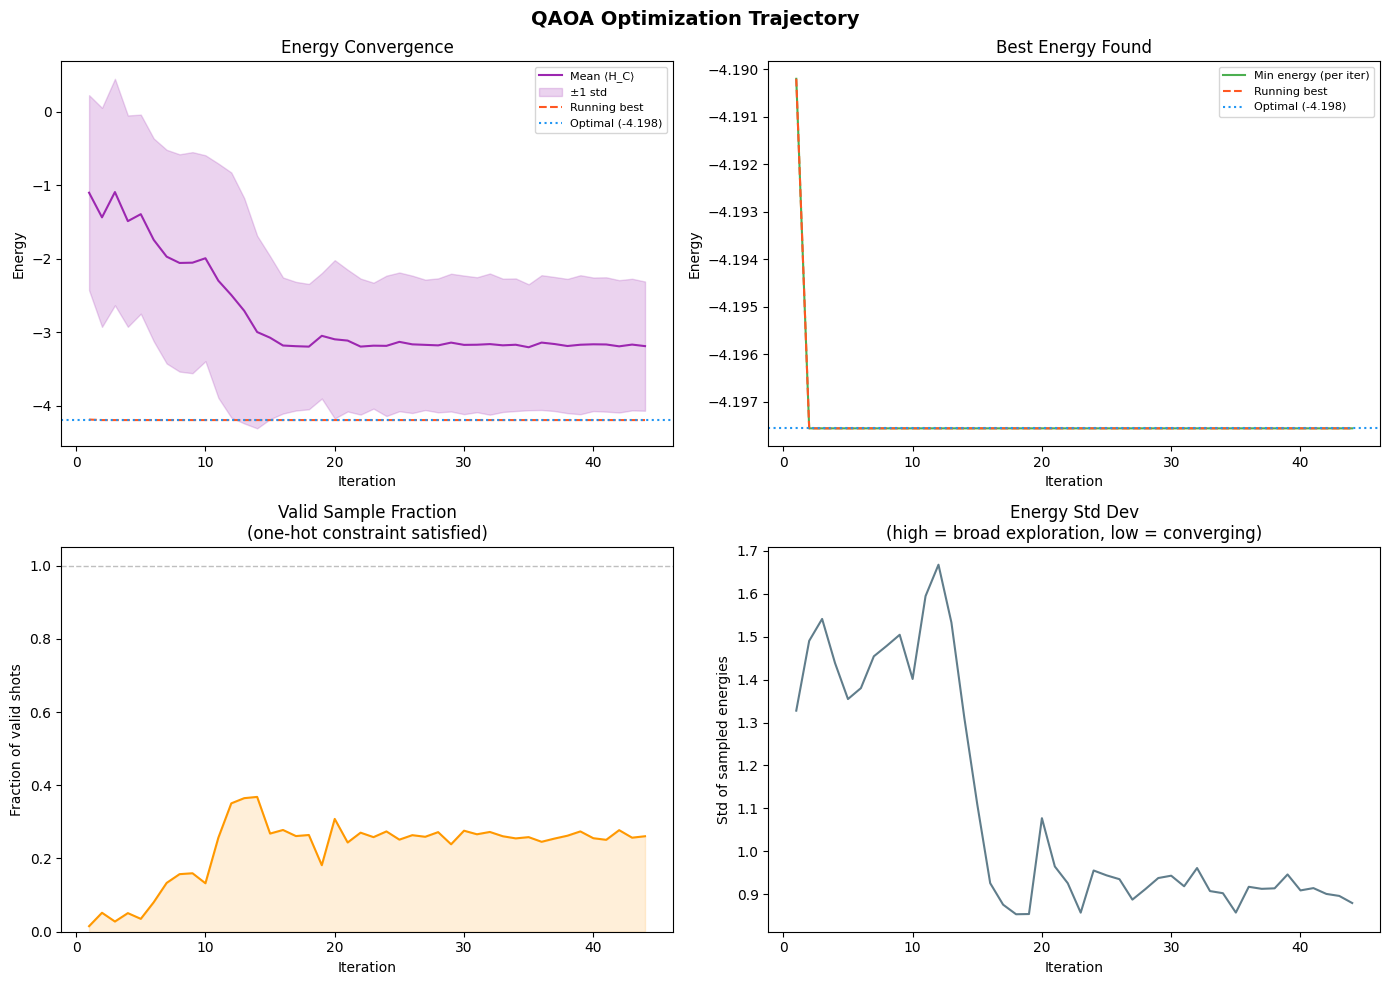

In [26]:

plot_convergence(history, bf_energy=results['Brute Force']['energy'])
